In [7]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 5.2 MB/s eta 0:00:20
   - -------------------------------------- 2.9/101.7 MB 6.1 MB/s eta 0:00:17
   -- ------------------------------------- 5.5/101.7 MB 8.0 MB/s eta 0:00:13
   --- ------------------------------------ 9.4/101.7 MB 10.7 MB/s eta 0:00:09
   ----- ---------------------------------- 12.8/101.7 MB 11.8 MB/s eta 0:00:08
   ------- -------------------------------- 18.4/101.7 MB 14.1 MB/s eta 0:00:06
   ---------- ----------------------------- 25.7/101.7 MB 17.0 MB/s eta 0:00:05
   ------------ --------------------------- 33.0/101.7 MB 19.4 MB/s eta 0:00:04
   ---------------- ----------------------- 41.2/101.7 MB 21.5 MB/s eta 0:00:03
   ------------------- -------------------- 49.5/101.7 MB 23.3 MB/s eta 0:00:03
   ---------------------- ----------------- 56.6/101.7 MB 24.3 MB


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
pip install pickle

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for pickle


In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import pickle

In [11]:
df = pd.read_csv("demandas.csv")

In [26]:
df

,data,id_loja,id_produto,categoria,regiao,nivel_estoque,unid_vendidas,unid_pedidas,preco,desconto,condicao_climatica,promocao,preco_concorrente,sazonalidade,epidemia,demanda
0,2022-01-01,S001,P0001,Eletronicos,Norte,195,102,252,72.72,5,Nevada,0,85.73,Inverno,0,115
1,2022-01-01,S001,P0002,Roupas,Norte,117,117,249,80.16,15,Nevada,1,92.02,Inverno,0,229
2,2022-01-01,S001,P0003,Roupas,Norte,247,114,612,62.94,10,Nevada,1,60.08,Inverno,0,157
3,2022-01-01,S001,P0004,Eletronicos,Norte,139,45,102,87.63,10,Nevada,0,85.19,Inverno,0,52
4,2022-01-01,S001,P0005,Alimentos,Norte,152,65,271,54.41,0,Nevada,0,51.63,Inverno,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Brinquedos,Norte,233,63,0,29.80,5,Nevada,0,32.23,Inverno,0,64
75996,2024-01-30,S005,P0017,Brinquedos,Norte,137,115,141,42.92,5,Nevada,0,40.73,Inverno,0,137
75997,2024-01-30,S005,P0018,Roupas,Norte,197,44,0,17.81,10,Nevada,0,19.41,Inverno,0,68
75998,2024-01-30,S005,P0019,Moveis,Norte,125,58,0,151.72,0,Nevada,0,143.71,Inverno,0,84


In [13]:
df.columns

Index(['data', 'id_loja', 'id_produto', 'categoria', 'regiao', 'nivel_estoque',
       'unid_vendidas', 'unid_pedidas', 'preco', 'desconto',
       'condicao_climatica', 'promocao', 'preco_concorrente', 'sazonalidade',
       'epidemia', 'demanda'],
      dtype='str')

In [36]:
features = [
    "preco",
    "desconto",
    "nivel_estoque",
    "promocao",
    "preco_concorrente",
    "categoria"
]

In [37]:
features

['preco',
 'desconto',
 'nivel_estoque',
 'promocao',
 'preco_concorrente',
 'categoria']

In [38]:
tagert = "demanda"

In [39]:
X = df[features].copy()

In [40]:
X

,preco,desconto,nivel_estoque,promocao,preco_concorrente,categoria
0,72.72,5,195,0,85.73,Eletronicos
1,80.16,15,117,1,92.02,Roupas
2,62.94,10,247,1,60.08,Roupas
3,87.63,10,139,0,85.19,Eletronicos
4,54.41,0,152,0,51.63,Alimentos
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Brinquedos
75996,42.92,5,137,0,40.73,Brinquedos
75997,17.81,10,197,0,19.41,Roupas
75998,151.72,0,125,0,143.71,Moveis


In [41]:
y = df[tagert]

In [42]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: demanda, Length: 76000, dtype: int64

In [43]:
label_encoders = {}
categorical_cols = X.select_dtypes(include="object").columns

C:\Users\AndreFelipeCiccoRiba\AppData\Local\Temp\ipykernel_32764\1712198137.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [44]:
categorical_cols

Index(['categoria'], dtype='str')

In [45]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [55]:
label_encoders

{'categoria': LabelEncoder()}

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2)

In [60]:
xgb = XGBRegressor(objective= "reg:squarederror", n_jobs= -1)

In [61]:
param_dict = {
    "num_estimators" : [200, 300, 500],
    "max_depth" : [3,4,6,8],
    "learning_rate" : [0.01,0.05,0.1],
    "subsample" : [0.7, 0.8, 1.0],
    "colsample_bytree" : [0.7,0.8,1.0],
    "min_child_weight" : [1,3,5]
}

In [62]:
random_search = RandomizedSearchCV(
    estimator= xgb,
    param_distributions= param_dict,
    n_iter= 25,
    scoring= "neg_mean_absolute_error",
    cv= 3,
    verbose= 1,
    n_jobs= -1
)

In [63]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategie

In [64]:
random_search.best_params_

{'subsample': 0.8,
 'num_estimators': 200,
 'min_child_weight': 5,
 'max_depth': 8,
 'learning_rate': 0.1,
 'colsample_bytree': 1.0}

In [65]:
best_model = random_search.best_estimator_

In [69]:
y_predict = best_model.predict(X_test)

In [73]:
rmse =  np.sqrt(mean_squared_error(y_test, y_predict))
rmse

np.float64(35.954029826184815)

In [74]:
best_model.feature_importances_

array([0.06493641, 0.02227809, 0.01852042, 0.54982835, 0.02294022,
       0.3214965 ], dtype=float32)

In [75]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index= X.columns
).sort_values(ascending=False)

In [77]:
feature_importance

promocao             0.549828
categoria            0.321496
preco                0.064936
preco_concorrente    0.022940
desconto             0.022278
nivel_estoque        0.018520
dtype: float32

<Axes: title={'center': 'Features Importantes'}>

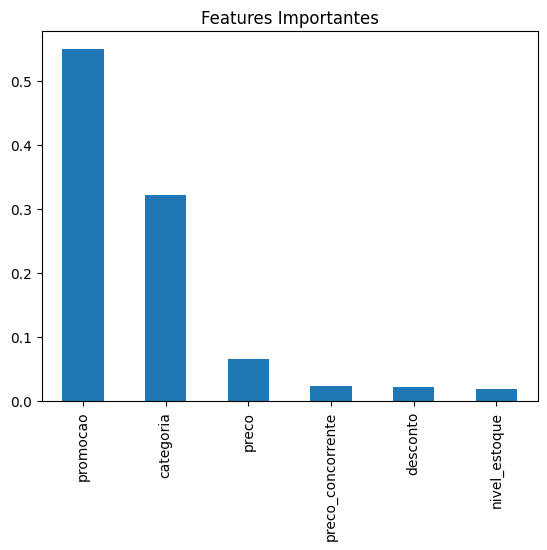

In [78]:
feature_importance.plot(kind="bar", title="Features Importantes")

In [79]:
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

In [80]:
with open("xgboost_demanda_modelo.pkl", "wb") as f:
    pickle.dump(best_model, f)